# Sensitivity Analysis of the RCMs 

Program to read in the zarr collection of an RCM and its corresponding FFDI files and explore FFDI drivers

This code does the permutation sensitivity analysis.


3-23-.10




#### required packages

In [1]:
import intake
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np

from glob import glob
import pathlib
import traceback
from datetime import datetime

from xclim.indices import (
    keetch_byram_drought_index,
    griffiths_drought_factor,
    mcarthur_forest_fire_danger_index
)

%load_ext autoreload
%autoreload 2


# importing sys
import sys
# adding plotting module to the system path
sys.path.insert(0, '/g/data/xv83/rxm599/acs/plotting_maps')
# import ACS plotting maps and Xarray.
from acs_plotting_maps import *
from acs_area_statistics import acs_regional_stats, get_regions

import geopandas as gpd
import pandas as pd
import regionmask

sys.path.insert(0, '/g/data/xv83/rxm599/acs/hazard_fire/paper2')
import sa as sa


ERROR 1: PROJ: proj_create_from_database: Open of /g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/share/proj failed


#### start a local Dask client

In [2]:
from dask.distributed import Client
import dask

# Set configuration options
dask.config.set({
    'distributed.comm.timeouts.connect': '90s',  # Timeout for connecting to a worker
    'distributed.comm.timeouts.tcp': '90s',  # Timeout for TCP communications
})

#cluster = LocalCluster(
#    n_workers=28,          # Number of workers
#    threads_per_worker=1 #Threads per worker
#    #memory_limit='8GB' # Memory limit per each worker commented out
#)
#client = Client(cluster)

client = Client()
client

2025-08-17 19:50:36,309 - distributed.preloading - INFO - Creating preload: /g/data/hh5/public/apps/dask-optimiser/schedplugin.py
2025-08-17 19:50:36,314 - distributed.utils - INFO - Reload module schedplugin from .py file
2025-08-17 19:50:36,341 - distributed.preloading - INFO - Import preload module: /g/data/hh5/public/apps/dask-optimiser/schedplugin.py
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38877 instead
  warnings.warn(


Modifying workers


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /node/gadi-cpu-bdw-0038.gadi.nci.org.au/38300/proxy/38877/status,
Dashboard: /node/gadi-cpu-bdw-0038.gadi.nci.org.au/38300/proxy/38877/status,Workers: 7
Total threads: 7,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45389,Workers: 7
Dashboard: /node/gadi-cpu-bdw-0038.gadi.nci.org.au/38300/proxy/38877/status,Total threads: 7
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34331,Total threads: 1
Dashboard: /node/gadi-cpu-bdw-0038.gadi.nci.org.au/38300/proxy/46715/status,Memory: 0 B
Nanny: tcp://127.0.0.1:35845,


In [3]:
import warnings
warnings.filterwarnings('ignore')

## Set parameters

In [32]:
# parameters
# 0,2,3 failed
mindex=0
#lon1=140; lon2=150 
#lat1=-45; lat2= -32
#lat1=-45 lat2= -40 lon1=144 lon2=149
lat1=-45
lat2= -40
lon1=144
lon2=149

#lon1=145 ; lon2=146
#lat1=-37 ; lat2=-36
t1='2015-01-01'
t2='2035-12-31'
dirstore='sa_2020'
# Parameters
mindex = 4
lat1 = -45
lat2 = -10
lon1 = 110
lon2 = 155
t1 = "2040-01-01"
t2 = "2060-01-10"
dirstore = "sa_2050"


In [ ]:
# extra info
mindexp100=mindex+100
mobs=39

## Obtain the desired catalogues of the simulations to processe

In [33]:
dtype='/g/data/ia39/ncra/fire/bias-output/'
zarr_path=dtype+ 'zarr/*ssp370*'
ffdi_path=dtype+'ffdi/*ssp370*FFDI*'
kbdi_path=dtype+'ffdi/*ssp370*KBDI*'
# observations 
zobs='/g/data/ia39/ncra/fire/bias-input/zarr/*ERA*' 
fobs='/g/data/ia39/ncra/fire/bias-input/ffdi/*ERA*FFDI*'
kobs='/g/data/ia39/ncra/fire/bias-input/ffdi/*ERA*KBDI*'

mRuns = sorted(glob(zarr_path)) + sorted(glob(zobs))
mFFDI = sorted(glob(ffdi_path))+ sorted(glob(fobs))
mKBDI = sorted(glob(kbdi_path)) + sorted(glob(kobs))
print(len(mRuns))
print(len(mFFDI))

# print code to ensure the files match
ifile=-1
for file in mRuns: 
    ifile=ifile+1
#    print(ifile, file)
ifile=-1
for file in mFFDI: 
    ifile=ifile+1
#    print(ifile, file)

24
24


# Process one ensemble 

In [34]:
# From one catalogue list save variables
ds0=xr.open_zarr(mRuns[mindex])
df0=xr.open_zarr(mFFDI[mindex])
dk0=xr.open_zarr(mKBDI[mindex])

print(mRuns[mindex])
print(mFFDI[mindex])
print(mKBDI[mindex])


# compute DF 
# kbdi has a 20 extra points at the start for DF calculation
if mindex != mobs: 
# for projections    
    pra = ds0.prAdjust.sel(time=slice(ds0.prAdjust.time[0],'2099-12-31'))
    kbdi=dk0.KBDI.sel(time=slice(pra.time[0],pra.time[-1] ))
    DF = griffiths_drought_factor(pra, kbdi)
else:
    print("obs")
    pra = ds0.pr.sel(time=slice(ds0.pr.time[0],'2099-12-31'))
    kbdi=dk0.KBDI.sel(time=slice(pra.time[0],pra.time[-1] ))
    DF = griffiths_drought_factor(pra, kbdi)

print(pra)
print(kbdi)


/g/data/ia39/ncra/fire/bias-output/zarr/AUST-05i_BOM_EC-Earth3_ssp370_r1i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day.zarr
/g/data/ia39/ncra/fire/bias-output/ffdi/AUST-05i_BOM_EC-Earth3_ssp370_r1i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day_FFDI.zarr
/g/data/ia39/ncra/fire/bias-output/ffdi/AUST-05i_BOM_EC-Earth3_ssp370_r1i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day_KBDI.zarr
<xarray.DataArray 'prAdjust' (time: 31046, lat: 691, lon: 886)>
dask.array<getitem, shape=(31046, 691, 886), dtype=float32, chunksize=(31046, 33, 43), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon      (lon) float64 112.0 112.0 112.1 112.2 ... 156.1 156.2 156.2 156.2
  * time     (time) datetime64[ns] 2015-01-01T12:00:00 ... 2099-12-31T12:00:00
Attributes:
    long_name:      Bias-Adjusted Precipitation
    regrid_method:  bilinear
    standard_name:  lwe_precipitation_rate
    units:          mm d-1
<xarray.DataArray 'KBDI'

In [35]:
# compute the 95% value from 20 years reference period
if mindex != mobs:
    tr1='2015-01-01'; tr2='2035-01-01'
else:
    tr1='2000-01-01'; tr2='2020-01-01'
    t1=tr1; t2=tr2
#    tr1='2003-01-01'; tr2='2023-12-31' # could be changed to get the most recent data
df1=df0.sel(time=slice(tr1,tr2))
d95a=df1.FFDI.quantile(.95,dim='time')


## mask info

In [36]:
%%time
# NCRA regions from acs_area_statistics code
# these are the names of your regions
regions = get_regions([
                           "australia"
                      ])
regions
# nrm_regions ncra_regions",


CPU times: user 8.21 s, sys: 429 ms, total: 8.64 s
Wall time: 8.46 s


<regionmask.Regions 'australia'>
overlap:  True

Regions:
0 AUS Australia

[1 regions]

In [37]:
mask_frac = regions.mask_3D(d95a)
#mask_frac = regions.mask_3D_frac_approx(d95) # not defined in 3-23.10

In [38]:
mask_ = mask_frac.isel(region=0)
mask_
d95=d95a.where(mask_).load()

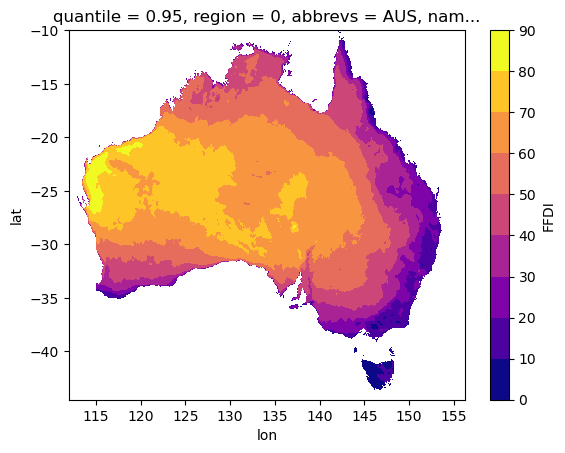

In [39]:
d95.plot(cmap='plasma',levels=10)

In [40]:
df2=df0.sel(time=slice(t1,t2))
ds2=ds0.sel(time=slice(t1, t2))
dk2=dk0.sel(time=slice(t1,t2))
dd2=DF.sel(time=slice(t1,t2))
# extract only the values greater than FFDI > 95%
dfe95=df0.FFDI.where(df2.FFDI > d95)
dse95=ds0.where(df2.FFDI > d95)
dke95=dk0.where(df2.FFDI > d95)
dde95=DF.where(df2.FFDI > d95)

<xarray.DataArray (lat: 691, lon: 886, time: 7305)>
dask.array<where, shape=(691, 886, 7305), dtype=float32, chunksize=(33, 43, 7305), chunktype=numpy.ndarray>
Coordinates:
  * lat       (lat) float64 -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon       (lon) float64 112.0 112.0 112.1 112.2 ... 156.1 156.2 156.2 156.2
  * time      (time) datetime64[ns] 2040-01-01T12:00:00 ... 2059-12-31T12:00:00
    quantile  float64 0.95
    region    int64 0
    abbrevs   <U3 'AUS'
    names     <U9 'Australia'
Attributes:
    units:

In [36]:
# fixed naming in UQ-DEC files
print(list(dse95.data_vars))
var=list(dse95.data_vars)
for jj in list(dse95.data_vars):
    if (jj == 'sfcWindAdjust'):
        qt=True
        ddnew=dse95.rename({'sfcWindAdjust': 'sfcWindmaxAdjust'})
        dse95=ddnew

print(list(dse95.data_vars))

['hursmaxAdjust', 'hursminAdjust', 'prAdjust', 'rsdsAdjust', 'sfcWindAdjust', 'tasmaxAdjust', 'tasminAdjust']
['hursmaxAdjust', 'hursminAdjust', 'prAdjust', 'rsdsAdjust', 'sfcWindmaxAdjust', 'tasmaxAdjust', 'tasminAdjust']


In [41]:
%%time
# Only create file if it does not exist
outf='/scratch/xv83/rxm599/'+f'{dirstore}/'+f'model_{mindexp100}_dde95.zarr'
print(outf)
if os.path.exists(outf):
    print("File exists!")
    ddtmp=xr.open_zarr(outf)
else:
    print("File does not exist.")
    dde95.to_zarr(outf, mode='w')
    ddtmp=xr.open_zarr(outf)

#print(dde95)
var_name = list(ddtmp.data_vars)[0]
dde95 = ddtmp[var_name]
#print(dde95)
dde95

/scratch/xv83/rxm599/sa_2050/model_4_dde95.zarr
File exists!
CPU times: user 34.8 ms, sys: 14.6 ms, total: 49.4 ms
Wall time: 55.1 ms


<xarray.DataArray '__xarray_dataarray_variable__' (lat: 691, lon: 886,
                                                   time: 7305)>
dask.array<open_dataset-__xarray_dataarray_variable__, shape=(691, 886, 7305), dtype=float32, chunksize=(33, 43, 7305), chunktype=numpy.ndarray>
Coordinates:
    abbrevs   <U3 ...
  * lat       (lat) float64 -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon       (lon) float64 112.0 112.0 112.1 112.2 ... 156.1 156.2 156.2 156.2
    names     <U9 ...
    quantile  float64 ...
    region    int64 ...
  * time      (time) datetime64[ns] 2040-01-01T12:00:00 ... 2059-12-31T12:00:00
Attributes:
    units:

In [51]:
%%time
#lat1=-42; lat2= -41; lon1=145; lon2=146;
# two versions 
if mindex != mobs: 
# for projections    
    tmax=dse95.tasmaxAdjust.sel(lon=slice(lon1,lon2),lat=slice(lat1,lat2 )) 
    hmin=dse95.hursminAdjust.sel( lon=slice(lon1,lon2),lat=slice(lat1,lat2 )) 
    wmax=dse95.sfcWindmaxAdjust.sel(lon=slice(lon1,lon2),lat=slice(lat1,lat2 )) 
else:
    tmax=dse95.tasmax.sel(lon=slice(lon1,lon2),lat=slice(lat1,lat2 )) 
    hmin=dse95.hursmin.sel( lon=slice(lon1,lon2),lat=slice(lat1,lat2 )) 
    wmax=dse95.sfcWindmax.sel(lon=slice(lon1,lon2),lat=slice(lat1,lat2 )) 
    
di=dde95.sel(lon=slice(lon1,lon2),lat=slice(lat1,lat2 )) 
# ffdi 
ffdi=dfe95.sel(lon=slice(lon1,lon2),lat=slice(lat1,lat2 )) 

l1=(lon1+lon2)*.5
l2=(lat1+lat2)*.5
#print(lat1,lat2,lon1,lon2)

# two versions 
if mindex != mobs: 
# for projections    
    tmax1=dse95.tasmaxAdjust.sel(lon=l1,lat=l2).compute()
    hmin1=dse95.hursminAdjust.sel(lon=l1,lat=l2).compute()
    wmax1=dse95.sfcWindmaxAdjust.sel(lon=l1,lat=l2).compute()
else:
    tmax1=dse95.tasmax.sel(lon=l1,lat=l2).compute()
    hmin1=dse95.hursmin.sel(lon=l1,lat=l2).compute()
    wmax1=dse95.sfcWindmax.sel(lon=l1,lat=l2).compute()
    
di1=dde95.sel(lon=l1,lat=l2).compute()
ffdi1=dfe95.sel(lon=l1,lat=l2).compute()


CPU times: user 1.94 s, sys: 240 ms, total: 2.18 s
Wall time: 11.4 s


132.5 -27.5


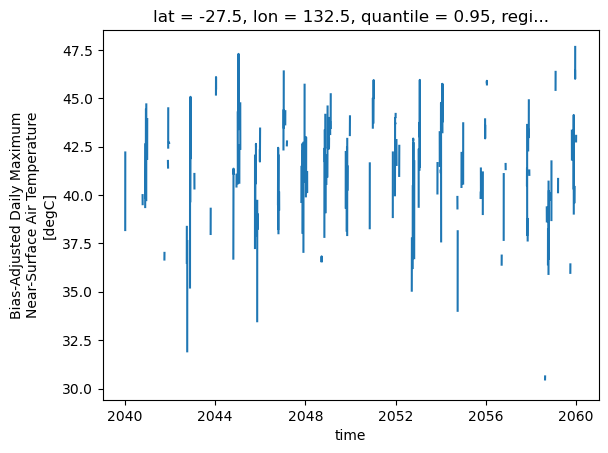

In [55]:
#ffdi.max(axis=2).plot()
print(l1,l2)
tmax1.plot()

In [56]:
%%time
r1=sa.xr_perm_importance(di,tmax,hmin,wmax,ffdi)
rr1=sa._perm_importance_1d(di1,tmax1,hmin1,wmax1,ffdi1)
#rr1=_perm_importance_1d(di,tmax,hmin,wmax,ffdi)
print(rr1)
print(r1)

[[1.27566658e-02 3.89649737e-01 4.31573496e-01 1.27440762e+00]
 [3.68274590e-03 3.55452529e-02 6.01061249e-02 1.03694594e-01]
 [9.12873745e-01 4.82880910e+00 1.64002700e+00 3.19429445e+00]]
<xarray.DataArray 'permutation_importance' (lat: 691, lon: 861, stat: 3, nvar: 4)>
dask.array<transpose, shape=(691, 861, 3, 4), dtype=float64, chunksize=(33, 43, 3, 4), chunktype=numpy.ndarray>
Coordinates:
    abbrevs   <U3 'AUS'
  * lat       (lat) float64 -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon       (lon) float64 112.0 112.0 112.1 112.2 ... 154.8 154.9 154.9 155.0
    names     <U9 'Australia'
    quantile  float64 0.95
    region    int64 0
  * nvar      (nvar) <U4 'DI' 'Tmax' 'Hmin' 'Wmax'
  * stat      (stat) <U4 'mean' 'std' 'diag'
CPU times: user 1.34 s, sys: 75.7 ms, total: 1.42 s
Wall time: 1.39 s


## Plot results

In [ ]:
%%time
r1.load()
outf1='/scratch/xv83/rxm599/'+f'{dirstore}/'+f'model_{mindexp100}_pa.nc'
print(mindex)
print(outf1)
r1.name='mean'
#ds = xr.merge([r1,r2,r3])  #,dfit,dfitb])

r1.to_netcdf(outf1,mode='w')


In [ ]:
dd=xr.open_dataset(outf1)
dd

CPU times: user 425 ms, sys: 22.6 ms, total: 448 ms
Wall time: 431 ms


Text(0.5, 1.0, 'Wmax')

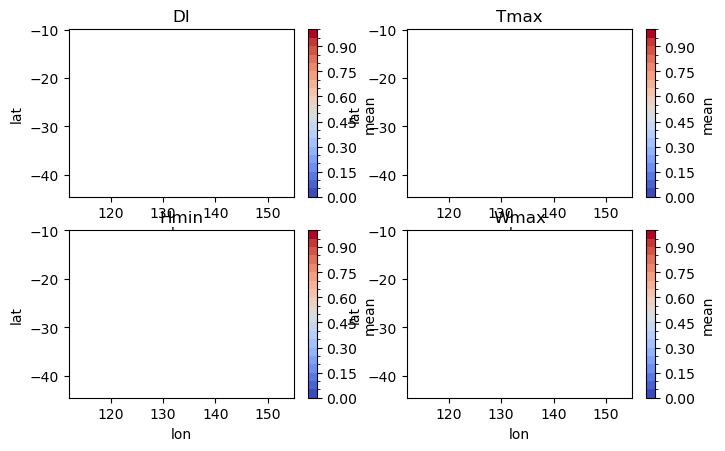

In [47]:
%%time
r1=dd['mean'].sel(stat='mean')
lev = np.linspace(0, 1, 21)
#lev = np.linspace(0, .5, 21)
plt.figure(figsize=(8, 10))
plt.subplot(4,2,1); r1.sel(nvar='DI').plot(levels=lev,cmap="coolwarm")
plt.title("DI")
plt.subplot(4,2,3); r1.sel(nvar='Hmin').plot(levels=lev,cmap="coolwarm")
plt.title("Hmin")
plt.subplot(4,2,2); r1.sel(nvar='Tmax').plot(levels=lev,cmap="coolwarm")
plt.title("Tmax")
plt.subplot(4,2,4); r1.sel(nvar='Wmax').plot(levels=lev,cmap="coolwarm")
plt.title("Wmax")


In [20]:
client.shutdown()